In [2]:
import pandas as pd
from clearml import Task
import numpy as np
import matplotlib.pyplot as plt

import sys
#from data import get_dataset
#from eval_utils import get_popularity_buckets

from IPython.display import display
import warnings
warnings.filterwarnings('ignore')


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.5 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "C:\ProgramData\anaconda3\envs\recbole\lib\runpy.py", line 196, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "C:\ProgramData\anaconda3\envs\recbole\lib\runpy.py", line 86, in _run_code
    exec(code, run_globals)
  File "C:\ProgramData\anaconda3\envs\recbole\lib\site-packages\ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "C:\ProgramData\anaconda3\envs\recbole\lib\site-packages\traitlets\config\application.py", line 1075, in launch_instance
    app.s

AttributeError: _ARRAY_API not found

In [3]:
%env CLEARML_WEB_HOST=https://app.clear.ml/
%env CLEARML_API_HOST=https://api.clear.ml
%env CLEARML_FILES_HOST=https://files.clear.ml
%env CLEARML_API_ACCESS_KEY=ABP1QYAF3E5FG24SDKULXIR2ESEUNL
%env CLEARML_API_SECRET_KEY=EeLEn8EveqxBKL7oBo1-TnIh2gMXw70D-3_EbH57gdVbMrywzLEcBSx_vAzHe-ul45o

env: CLEARML_WEB_HOST=https://app.clear.ml/
env: CLEARML_API_HOST=https://api.clear.ml
env: CLEARML_FILES_HOST=https://files.clear.ml
env: CLEARML_API_ACCESS_KEY=ABP1QYAF3E5FG24SDKULXIR2ESEUNL
env: CLEARML_API_SECRET_KEY=EeLEn8EveqxBKL7oBo1-TnIh2gMXw70D-3_EbH57gdVbMrywzLEcBSx_vAzHe-ul45o


In [4]:
"""t = Task.get_task("f257ebe1ce8749e1a5fba54b0c59ff3c")
item_emb = t.artifacts["embeddings_item"].get()
seq_emb = t.artifacts["embeddings_seq"].get()
holdout_ = t.artifacts["holdout_test"].get()"""

't = Task.get_task("f257ebe1ce8749e1a5fba54b0c59ff3c")\nitem_emb = t.artifacts["embeddings_item"].get()\nseq_emb = t.artifacts["embeddings_seq"].get()\nholdout_ = t.artifacts["holdout_test"].get()'

In [5]:
"""task_ids = {
    "BT": "f257ebe1ce8749e1a5fba54b0c59ff3c",
    "FCE": "ba81ff69615046dd867243c47105db2f",
    "SCE": "3b0b07003b7c433ca95139446ccae368",
    #"Dross": "701a0a1733224b69bcfc9f2e527221cd",
    #"gBCE": "7789db0ed37243538cdf85db49a7cb29"
}

item_emb_arr = []
seq_emb_arr = []

for k,v in task_ids.items():
    if v != "":
        task = Task.get_task(v)
        item_emb_arr.append(task.artifacts["embeddings_item"].get())
        seq_emb_arr.append(task.artifacts["embeddings_seq"].get())"""

"""data_description = {
    "items": "itemid",
    "n_items": len(item_emb)
}"""

'data_description = {\n    "items": "itemid",\n    "n_items": len(item_emb)\n}'

In [6]:
d_task_ids = {
    "MovieLens 1M": {
        "BT": "f257ebe1ce8749e1a5fba54b0c59ff3c",
        "FCE": "ba81ff69615046dd867243c47105db2f",
        "SCE": "3b0b07003b7c433ca95139446ccae368",
    },
    "YELP": {
        "BT": "d1787bf27f174ca59ab8975d18bb08f4",
        "FCE": "7a1b8b91e42b4fc1ade15034d79918b6",
        "SCE": "79d31a7ec0524bdca4c0608754319df5"
    },
    "Gowalla": {
        "BT": "7faea67c91fa4d238df04aebcaa9df02",
        "FCE": "85c14515dc2447069e7efb5a94af98ab",
        "SCE": "c98dcaa9fa5646b692df74f814de2cf3"
    }
}

item_emb_arr = {}
seq_emb_arr = {}
d_houldout_ = {}
d_data_description = {}

for dataset, task_ids in d_task_ids.items():
    item_emb_arr[dataset] = []
    seq_emb_arr[dataset] = []
    for k, v in task_ids.items():
        if v != "":
            task = Task.get_task(v)
            it_emb = task.artifacts["embeddings_item"].get()
            item_emb_arr[dataset].append(it_emb)
            seq_emb_arr[dataset].append(task.artifacts["embeddings_seq"].get())
            d_houldout_[dataset] = task.artifacts["holdout_test"].get()
    d_data_description[dataset] = {
        "items": "itemid",
        "n_items": len(it_emb)
    }

In [7]:
d_data_paths = {
    "MovieLens 1M": "None",
    "YELP": "data/yelp.csv",
    "Gowalla": "data/gowalla.csv"
}
d_data = {}

for dataset, dpath in d_data_paths.items():
    ds = get_dataset(path=dpath)
    df_train = ds[0]
    pop_buckets = get_popularity_buckets(df_train, ds[1])
    d_data[dataset] = {
        "ds": df_train,
        "pop_buckets": pop_buckets
    }
    

NameError: name 'get_dataset' is not defined

In [8]:
def topidx(a, topn):
    parted = np.argpartition(a, -topn)[-topn:]
    return parted[np.argsort(-a[parted])]

def topn_recommendations(scores, topn=10):
    recommendations = np.apply_along_axis(topidx, 1, scores, topn)
    return recommendations



In [180]:
def plot_model_comparison0(seq_embeddings_arr, item_embeddings_arr, holdout_, data_description, model_names, ds_name,
                          neg_samples=300, num_users=30, seed=0):
    import numpy as np
    import matplotlib.pyplot as plt
    from numpy.random import RandomState
    from scipy.stats import gaussian_kde

    rng = RandomState(seed)
    holdout_items = holdout_[data_description["items"]].values[:1000]
    M = len(seq_embeddings_arr)
    x_positions = np.linspace(0, M - 1, M)
    fig, ax = plt.subplots(figsize=(6, 6))
    max_width = 0.3  # controls the horizontal width of each density bar

    for m, (seq_emb, item_emb) in enumerate(zip(seq_embeddings_arr, item_embeddings_arr)):
        # Compute scores and select users with the holdout item in top recommendations
        scores = seq_emb @ item_emb.T
        top_recs = topn_recommendations(scores)
        good_users = np.where(top_recs == holdout_items.reshape(-1, 1))[0]
        good_users = np.arange(len(holdout_items))

        # Sample users and extract embeddings for positives and negatives
        users_sample = rng.choice(good_users, min(num_users, len(good_users)), replace=False)
        seq_sample = seq_emb[users_sample]
        pos_sample = item_emb[holdout_items][users_sample]
        n_items = data_description['n_items']
        neg_idx = np.concatenate([
            rng.choice(np.delete(np.arange(n_items), holdout_items[i]), neg_samples, replace=False)
            for i in np.arange(len(holdout_items))[users_sample]
        ])
        neg_sample = item_emb[neg_idx]

        # Aggregate dot product scores (as similarity) for positives and negatives
        pos_scores = np.array([np.dot(pos_sample[i], seq_sample[i])
                               for i in range(len(seq_sample))])
        neg_scores = np.concatenate([
            np.dot(neg_sample[i * neg_samples:(i + 1) * neg_samples], seq_sample[i])
            for i in range(len(seq_sample))
        ])

        #pos_scores = pos_scores / pos_scores.max()
        #neg_scores = neg_scores / neg_scores.max()

        x = x_positions[m]
        # Plot density for negatives (above y=0)
        if neg_scores.size > 1:
            kde_neg = gaussian_kde(neg_scores)
            y_neg = np.linspace(neg_scores.min(), neg_scores.max(), 100)
            dens_neg = kde_neg(y_neg) / kde_neg(y_neg).max() * max_width
            ax.fill_betweenx(y_neg, x - dens_neg, x + dens_neg, color='red', alpha=0.5,
                             label='Negatives' if m == 0 else "")
        # Plot density for positives (mirrored below y=0)
        if pos_scores.size > 1:
            kde_pos = gaussian_kde(pos_scores)
            y_pos = np.linspace(pos_scores.min(), pos_scores.max(), 100)
            dens_pos = kde_pos(y_pos) / kde_pos(y_pos).max() * max_width
            ax.fill_betweenx(y_pos, x - dens_pos, x + dens_pos, color='blue', alpha=0.5,
                             label='Positives' if m == 0 else "")
        # Mark the user (baseline at y=0)
        ax.scatter(x, 0, color='green', marker='x', s=100, label='User' if m == 0 else "")

    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_xlabel("Models")
    ax.set_ylabel("Item dot product")
    ax.set_title(f"{ds_name}. Density Plot of Scores")
    ax.set_xticks(x_positions)
    ax.set_xticklabels(model_names)
    ax.legend()
    #plt.show()
    return ax


def plot_model_comparison(seq_embeddings_arr,
                        item_embeddings_arr,
                        holdout_,
                        data_description,
                        model_names,
                        ds_name,
                        neg_samples=300,
                        num_users=30,
                        seed=3838,
                        n_points=1000,
                        y_label = False
                         ):
    import numpy as np
    import matplotlib.pyplot as plt
    from numpy.random import RandomState
    from scipy.stats import gaussian_kde
    import matplotlib.gridspec as gridspec

    rng = RandomState(seed)
    holdout_items = holdout_[data_description["items"]].values[:1000]
    M = len(seq_embeddings_arr)
    x_positions = np.arange(M)

    # Layout
    fig = plt.figure(figsize=(8, 6))
    gs = gridspec.GridSpec(2, 1, height_ratios=[6, 2], hspace=0.08)
    ax = fig.add_subplot(gs[0])
    ax_bar = fig.add_subplot(gs[1], sharex=ax)

    # Aesthetic tweaks
    ax.grid(axis='y', linestyle='--', alpha=0.6)
    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)
        ax_bar.spines[spine].set_visible(False)
    ax.set_title(f"{ds_name}: Density & Overlap", pad=12, fontsize=22)
    if y_label:
        ax.set_ylabel("Scores", labelpad=10, fontsize=22)
        ax_bar.set_ylabel("Overlap", labelpad=10, fontsize=22)

    overlaps = []
    for m, (seq_emb, item_emb) in enumerate(zip(seq_embeddings_arr, item_embeddings_arr)):
        # sample users & compute scores
        users = rng.choice(np.arange(len(holdout_items)),
                           min(num_users, len(holdout_items)), replace=False)
        seq_s = seq_emb[users]
        pos_s = item_emb[holdout_items][users]
        neg_idx = np.concatenate([
            rng.choice(
                np.delete(np.arange(data_description['n_items']), holdout_items[i]),
                neg_samples, replace=False
            ) for i in users
        ])
        neg_s = item_emb[neg_idx]

        pos_scores = np.dot(pos_s, seq_s.T).diagonal()
        neg_scores = np.concatenate([
            np.dot(neg_s[i*neg_samples:(i+1)*neg_samples], seq_s[i])
            for i in range(len(seq_s))
        ])

        # KDE overlap fraction (for bar)
        kde_p = gaussian_kde(pos_scores)
        kde_n = gaussian_kde(neg_scores)
        lo, hi = min(pos_scores.min(), neg_scores.min()), max(pos_scores.max(), neg_scores.max())
        xs = np.linspace(lo, hi, n_points)
        p, n = kde_p(xs), kde_n(xs)
        overlap = np.trapz(np.minimum(p, n), xs) / np.trapz(p, xs)
        overlaps.append(overlap)

        # plot negative density (red)
        width = 0.3
        y_neg = np.linspace(neg_scores.min(), neg_scores.max(), 200)
        dens_neg = gaussian_kde(neg_scores)(y_neg)
        dens_neg = dens_neg / dens_neg.max() * width
        ax.fill_betweenx(y_neg, m - dens_neg, m + dens_neg,
                         color='red', alpha=0.4, label='Negatives' if m==0 else "")

        # plot positive density (blue)
        y_pos = np.linspace(pos_scores.min(), pos_scores.max(), 200)
        dens_pos = gaussian_kde(pos_scores)(y_pos)
        dens_pos = dens_pos / dens_pos.max() * width
        ax.fill_betweenx(y_pos, m - dens_pos, m + dens_pos,
                         color='blue', alpha=0.4, label='Positives' if m==0 else "")

        # user marker
        ax.scatter(m, 0, color='green', marker='x', s=60, label='User' if m==0 else "")

    # Finalize main density plot
    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_xticks(x_positions)
    ax.set_xticklabels([])
    ax.legend(loc='lower right', fontsize=15)
    ax.set_xticks([])
    ax.xaxis.set_visible(False)
    ax.tick_params(axis='x', which='both', labelbottom=False)

    # Overlap bars (purple)
    bars = ax_bar.bar(x_positions, overlaps, width=0.6, color='purple', alpha=0.7)
    ax_bar.set_ylim(0, 1)
    ax_bar.set_xticks(x_positions)
    ax_bar.set_xticklabels(model_names, rotation=45, ha='right', fontsize=20)
    for bar, ov in zip(bars, overlaps):
        ax_bar.text(bar.get_x() + bar.get_width()/2, ov + 0.02,
                    f"{ov:.2f}", ha='center', va='bottom', fontsize=20)
    
    plt.tight_layout()

In [10]:
#plot_model_comparison(seq_emb_arr, item_emb_arr, holdout_, data_description, model_names=task_ids.keys(), neg_samples=1000)

In [11]:
"""mla = get_dataset(path='None')
df_ml = mla[0]
ml_pb = get_popularity_buckets(df_ml, mla[1])"""

"mla = get_dataset(path='None')\ndf_ml = mla[0]\nml_pb = get_popularity_buckets(df_ml, mla[1])"

In [154]:
def get_buckets_emb_norm(item_emb, pop_buckets):
    ml_emb = np.linalg.norm(item_emb, axis=1)
    ml_norm = pd.DataFrame({
        "itemid": np.arange(len(item_emb)),
        "norm": np.linalg.norm(item_emb, axis=1)
    })
    ml_norm["bucket"] = ml_norm["itemid"].map(pop_buckets)
    bn = ml_norm.groupby("bucket")["norm"].mean()
    bn = bn / bn.max()
    return bn

def plot_norm_bars(bns, names, ds_name):
    metric_names = ["1", "2", "3"]
    models = names
    x = np.arange(len(metric_names))  # the label locations
    k = len(models)
    width = 0.4 / k  # width for each bar

    fig, ax = plt.subplots(figsize=(8, 6))
    for i, model in enumerate(models):
        ax.bar(x + i * width, bns[i].values, width, label=model, alpha = 0.7)

    # Formatting the plot
    ax.set_xlabel('Buckets')
    ax.set_ylabel('Item emebddings norm')
    ax.set_xticks(x + width * (k - 1) / 2)
    ax.set_xticklabels(metric_names)
    ax.legend(loc='lower left')
    ax.set_title(f"{ds_name}. Popularity buckets item emebedding norms")

In [41]:
#get_buckets_emb_norm(item_emb_arr[0])

In [42]:
#get_buckets_emb_norm(item_emb_arr[1])

In [43]:
#get_buckets_emb_norm(item_emb_arr[2])

In [45]:
"""plot_norm_bars([
    get_buckets_emb_norm(item_emb_arr[i])
    for i in range(len(item_emb_arr))
], names=list(task_ids.keys())[:3])"""

'plot_norm_bars([\n    get_buckets_emb_norm(item_emb_arr[i])\n    for i in range(len(item_emb_arr))\n], names=list(task_ids.keys())[:3])'

In [165]:
dataset

'Gowalla'

In [ ]:
## Multiple datasets

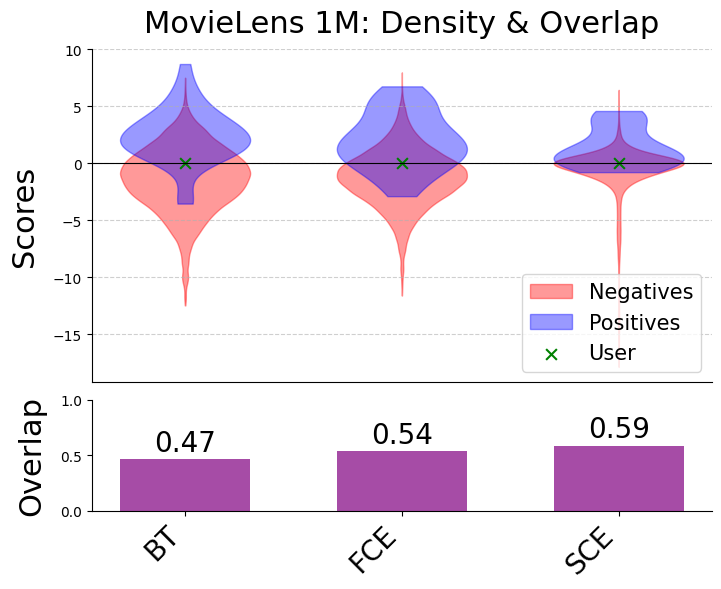

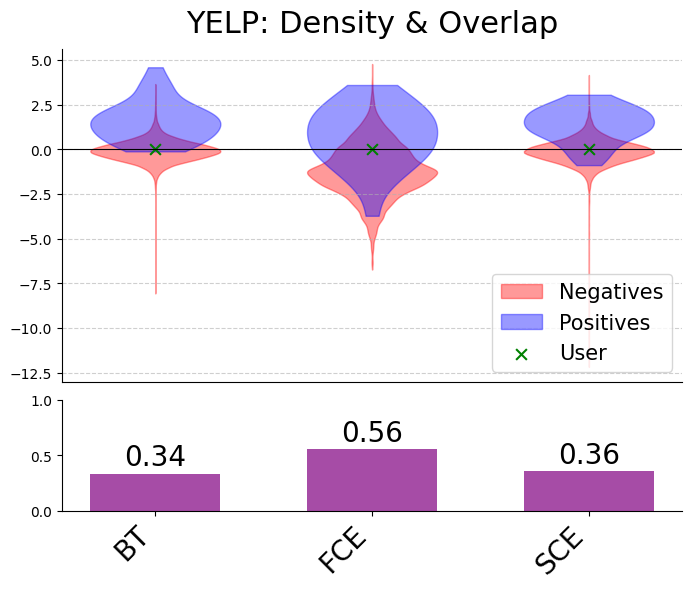

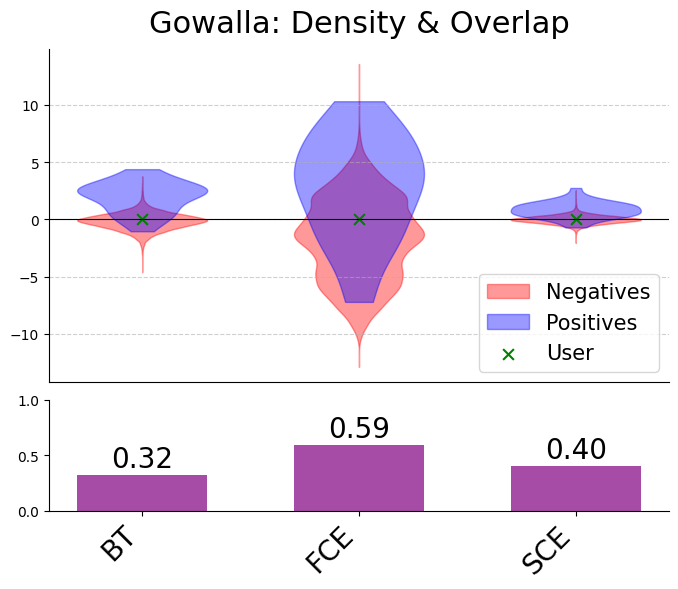

In [181]:
for dataset, item_emb_arr_i in item_emb_arr.items():
    plot_model_comparison(
        seq_emb_arr[dataset], 
        item_emb_arr[dataset], 
        d_houldout_[dataset], 
        d_data_description[dataset], 
        model_names=d_task_ids[dataset].keys(),
        ds_name=dataset,
        neg_samples=1000,
        seed = 7,
        y_label=True if dataset == "MovieLens 1M" else False
    )
    plt.savefig(f"./plots/scores_density/{dataset}.png")
    #break

In [45]:
def kde_overlap_ratio(pos_scores, neg_scores, n_points=1000):
    # Fit KDEs (they each integrate to 1)
    from scipy.stats import gaussian_kde
    kde_p = gaussian_kde(pos_scores)
    kde_n = gaussian_kde(neg_scores)
    # Build a common grid
    pos_scores = np.array(pos_scores)
    neg_scores = np.array(neg_scores)
    x_min = min(pos_scores.min(), neg_scores.min())
    x_max = max(pos_scores.max(), neg_scores.max())
    x_grid = np.linspace(x_min, x_max, n_points)
    # Evaluate densities
    p = kde_p(x_grid)
    n = kde_n(x_grid)
    # Numerical integration of the pointwise minimum
    overlap_area = np.trapz(np.minimum(p, n), x_grid)
    pos_area = np.trapz( p, np.linspace(pos_scores.min(), pos_scores.max(), n_points) )
    return overlap_area / pos_area

In [46]:
pos_scores = [0.9, 0.8, 0.8, 0.7, 0.5, 0.5, 0.5, 0.1, 0.1]
neg_scores = [0.5, 0.1, -0.2, -.3, -.3, -0.1, 0.0]

kde_overlap_ratio(pos_scores, neg_scores, 100)

np.float64(0.6669445417122636)

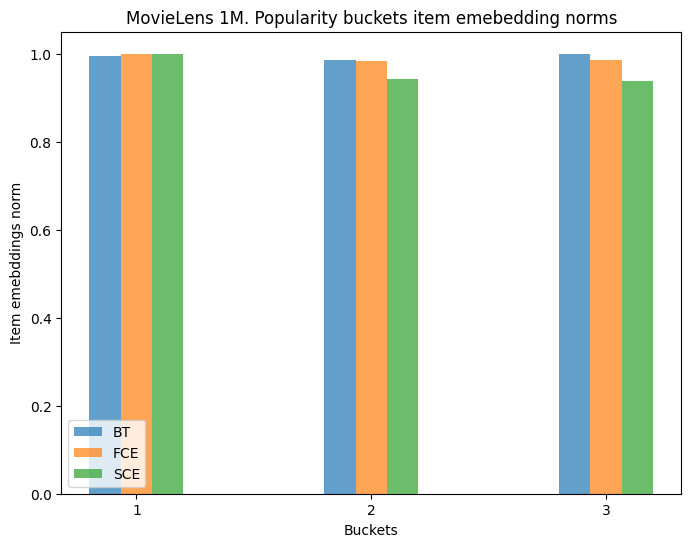

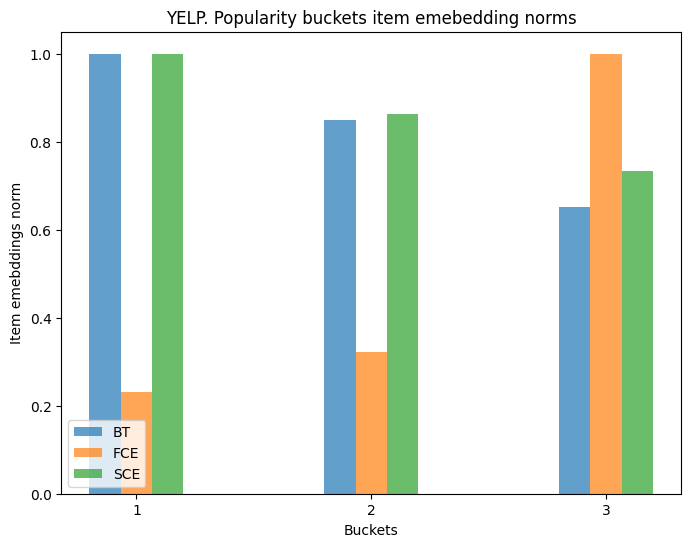

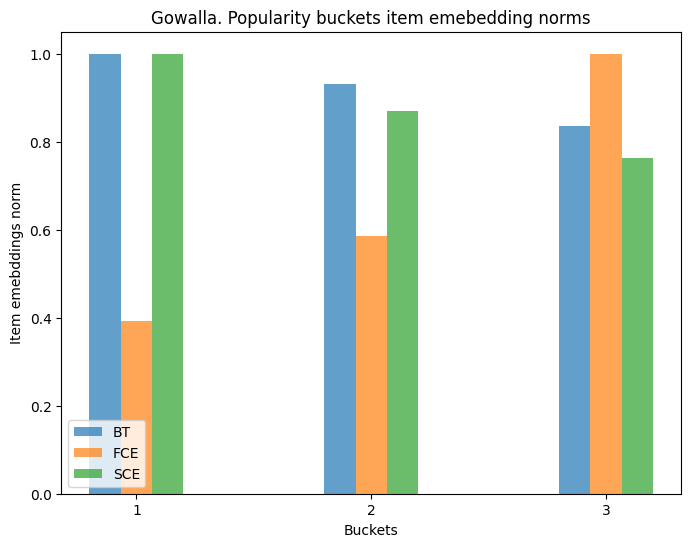

In [18]:
for dataset, item_emb_arr_i in item_emb_arr.items():
    plot_norm_bars([
        get_buckets_emb_norm(
            item_emb_arr[dataset][i], 
            pop_buckets = d_data[dataset]["pop_buckets"]
        )
        for i in range(len(item_emb_arr[dataset]))
    ], names=list(d_task_ids[dataset].keys()), ds_name=dataset)